In [ ]:
# use the simple moving average crossover strategy and python to get buy and sell signals. 

In [48]:
#importing the libraries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [47]:
#load the data
import pandas as pd

df = pd.read_csv('JPM_2024_daily.csv')
df.head()


,Date,Open,High,Low,Close,Volume
0,01/02/2024,160.996675,163.929256,160.825297,163.843567,9977400
1,01/03/2024,163.634102,163.805479,162.215414,163.129471,9852300
2,01/04/2024,163.474351,166.070557,163.378545,164.212021,11972500
3,01/05/2024,164.269495,166.099293,164.269495,165.035904,10066000
4,01/08/2024,164.796417,165.122136,162.372660,164.796417,11229900


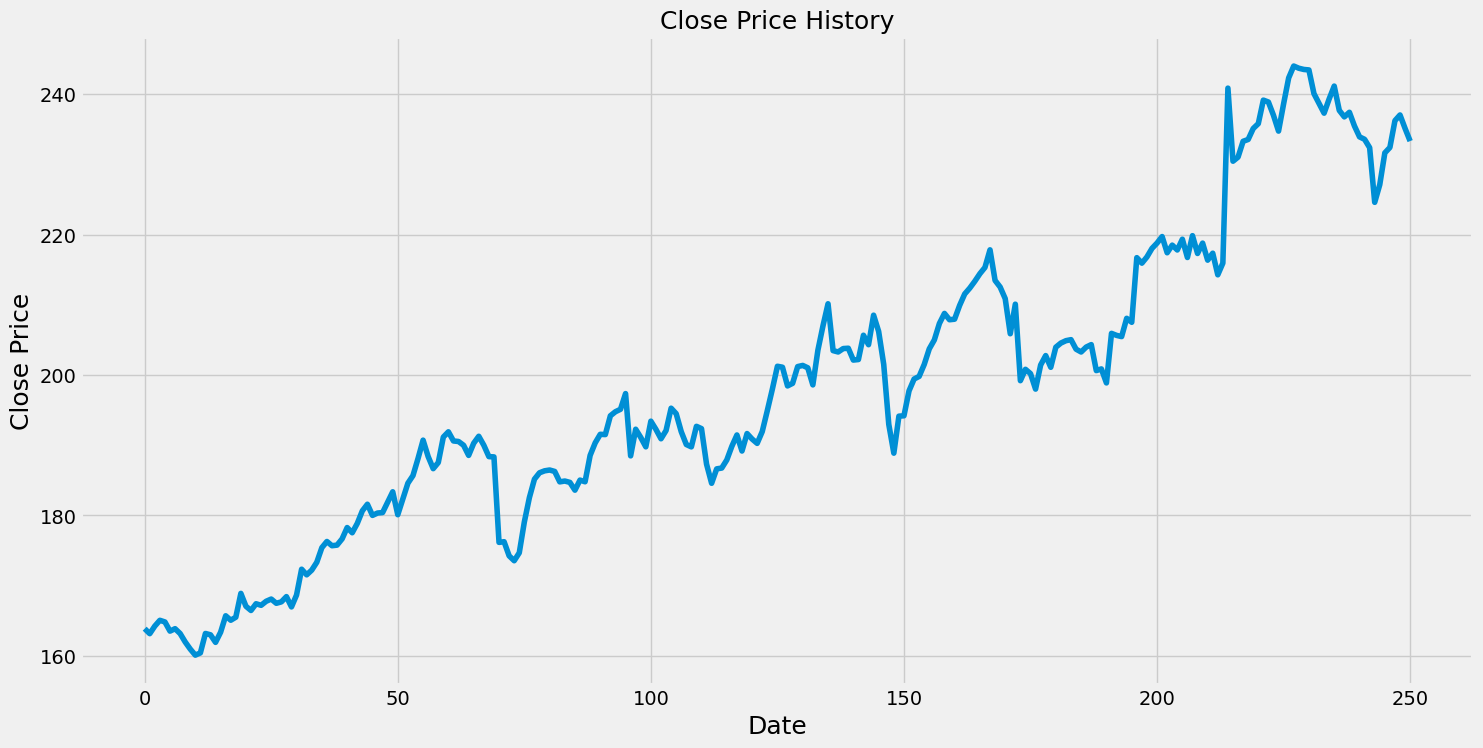

In [46]:
#visualize show the close price history

plt.figure(figsize=(16, 8))
plt.title('Close Price History', fontsize=18)
plt.plot(df['Close'], label='Close Price')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price', fontsize=18)
plt.show()


In [35]:
# create a function to calculate the simple moving average or SMA. 
def SMA(data, period=30, column='Close'):
    return data[column].rolling(window=period).mean()


In [49]:
# create two new columns 20 day and 50 day sma to the dataframe

df['SMA20'] = SMA(df, period=20)
df['SMA50'] = SMA(df, period=50)


In [50]:
# get the buy and sell signals

df['Signal'] = np.where(df['SMA20'] > df['SMA50'], 1, 0)
df['Position'] = df['Signal'].diff()

df['Buy'] = np.where(df['Position'] == 1, df['Close'], np.nan)
df['Sell'] = np.where(df['Position'] == -1, df['Close'], np.nan)

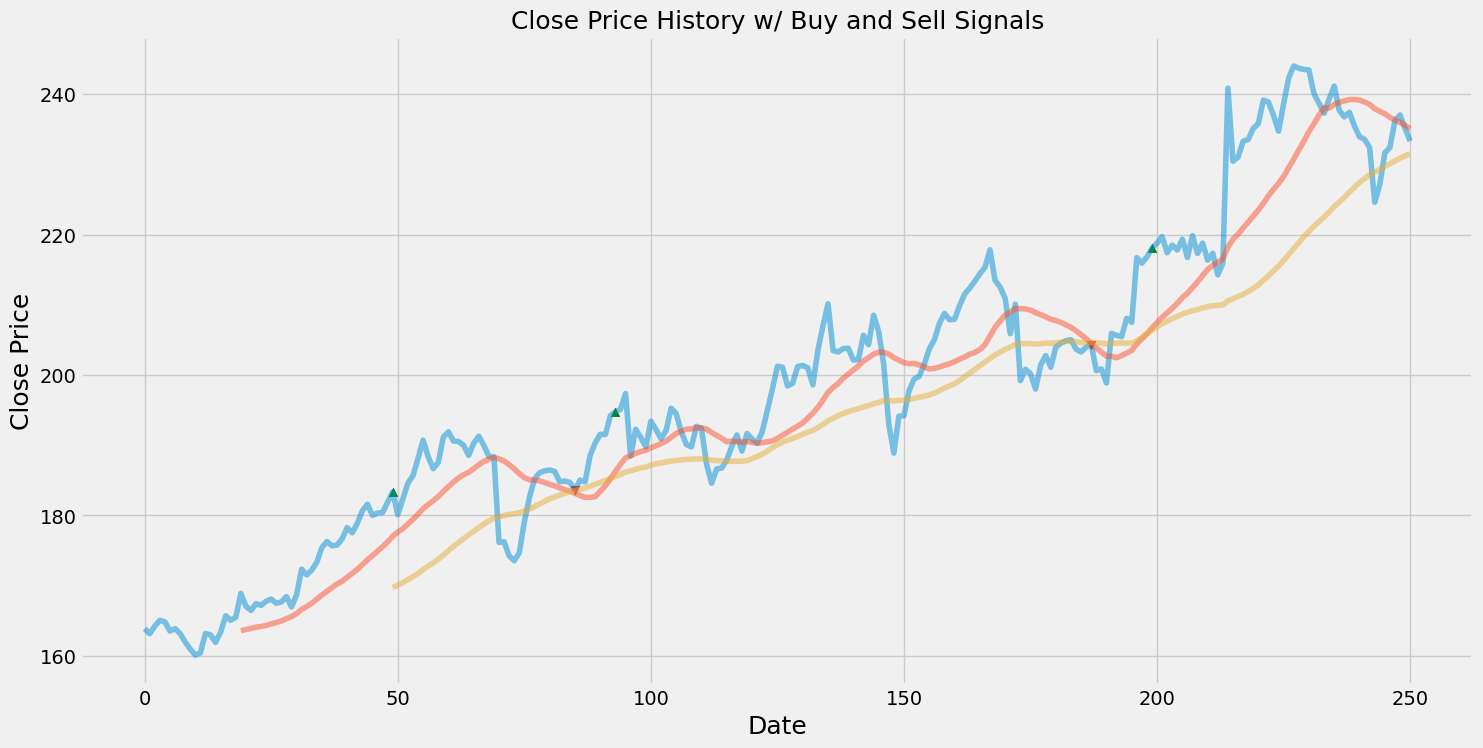

In [51]:
#visually show the close price with the SMAs and the buy and sell signals

plt.figure(figsize=(16, 8))
plt.title('Close Price History w/ Buy and Sell Signals', fontsize=18)
plt.plot(df['Close'], label='Close Price', alpha=0.5)

plt.plot(df['SMA20'], label='SMA20', alpha=0.5)
plt.plot(df['SMA50'], label='SMA50', alpha=0.5)

plt.scatter(df.index, df['Buy'], alpha=1, label= 'buy signal', marker='^', color='green')
plt.scatter(df.index, df['Sell'], alpha=1, label= 'sell signal', marker='v', color='red')

plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price', fontsize=18)
plt.show()